# Speech Enhancement — U-Net Baseline  
### Supervised denoising via Ideal Ratio Mask (IRM) prediction

This notebook implements a U-Net-based speech enhancement system operating on log-magnitude spectrograms.  
The model learns to predict Ideal Ratio Masks (IRM) for noisy speech signals.

---

## Models compared

| Model | Type |
|------|------|
| Noisy baseline | No processing |
| Spectral Subtraction (SS) | Classical signal processing |
| Geometric Spectral Subtraction (GSS) | Classical signal processing |
| MLP (IRM masking) | Fully-connected baseline |
| U-Net (IRM masking) | Convolutional deep learning |

# 1. Environment setup

In [12]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import soundfile as sf
import librosa
import librosa.display
import json
from pathlib import Path
from IPython.display import Audio, display, HTML
import os

REPO_ROOT = Path(os.getcwd()).parent

CLEAN_DIR = REPO_ROOT / "data" / "raw" / "wavs" / "test" / "clean"
NOISY_DIR = REPO_ROOT / "data" / "raw" / "wavs" / "test" / "noisy"

MODEL_DIR = REPO_ROOT / "outputs" / "models" / "unet"
RESULTS_DIR = REPO_ROOT / "outputs" / "results"

EXAMPLE_FILES = ["00005.wav", "00009.wav"]

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", DEVICE)
print("Torch:", torch.__version__)
print("Librosa:", librosa.__version__)

Device: cuda
Torch: 2.6.0+cu124
Librosa: 0.11.0


# 2. Why U-Net instead of MLP?

The MLP baseline operates on flattened spectrogram windows, which removes the explicit 2D structure of the signal.

In contrast, the U-Net treats the spectrogram as an image:

- Time axis → horizontal dimension
- Frequency axis → vertical dimension

This allows the model to exploit:

- Local spectral patterns (harmonics, formants)
- Temporal continuity of speech
- Frequency-band structure of noise

Unlike the MLP, which learns global mappings from vectors, the U-Net learns a structured transformation over the entire time-frequency plane.

# 3. STFT configuration

In [13]:
SR = 16000
N_FFT = 512
HOP_LENGTH = 128
FREQ_BINS = N_FFT // 2 + 1

print("STFT configuration")
print(f"Sample rate: {SR}")
print(f"FFT bins: {FREQ_BINS}")
print(f"Hop length: {HOP_LENGTH}")

STFT configuration
Sample rate: 16000
FFT bins: 257
Hop length: 128


# 4. Dataset visualization

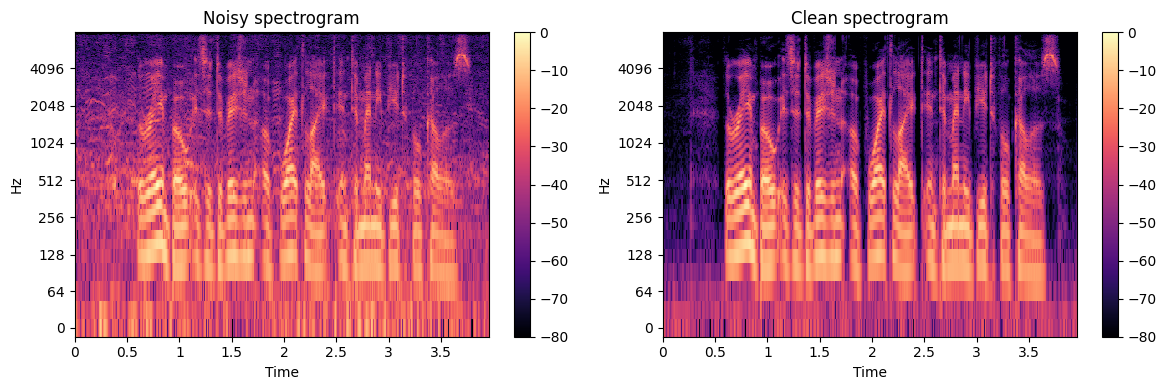

In [14]:
example_clean = CLEAN_DIR / EXAMPLE_FILES[0]
example_noisy = NOISY_DIR / EXAMPLE_FILES[0]

y_clean, _ = sf.read(example_clean)
y_noisy, _ = sf.read(example_noisy)

D_clean = librosa.stft(y_clean, n_fft=N_FFT, hop_length=HOP_LENGTH)
D_noisy = librosa.stft(y_noisy, n_fft=N_FFT, hop_length=HOP_LENGTH)

mag_clean = np.abs(D_clean)
mag_noisy = np.abs(D_noisy)

plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
librosa.display.specshow(
    librosa.amplitude_to_db(mag_noisy, ref=np.max),
    sr=SR, hop_length=HOP_LENGTH, y_axis="log", x_axis="time"
)
plt.title("Noisy spectrogram")
plt.colorbar()

plt.subplot(1,2,2)
librosa.display.specshow(
    librosa.amplitude_to_db(mag_clean, ref=np.max),
    sr=SR, hop_length=HOP_LENGTH, y_axis="log", x_axis="time"
)
plt.title("Clean spectrogram")
plt.colorbar()

plt.tight_layout()
plt.show()

# 5. U-Net model

The U-Net is a convolutional encoder–decoder network designed to predict Ideal Ratio Masks (IRM) directly from log-magnitude spectrograms.

Unlike the MLP baseline, it preserves spatial structure and uses skip connections to retain fine-grained spectral details lost during downsampling.

In [15]:
import torch
import torch.nn as nn
import torch.nn.functional as F


class ConvBlock(nn.Module):
  def __init__(self, in_channels: int, out_channels: int, dropout: float = 0.0):
    super().__init__()
    self.block = nn.Sequential(
      nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False),
      nn.BatchNorm2d(out_channels),
      nn.ReLU(inplace=True),
      nn.Dropout2d(dropout),
      nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
      nn.BatchNorm2d(out_channels),
      nn.ReLU(inplace=True),
    )

  def forward(self, x):
    return self.block(x)


class EncoderBlock(nn.Module):
  def __init__(self, in_channels: int, out_channels: int, dropout: float = 0.0):
    super().__init__()
    self.conv = ConvBlock(in_channels, out_channels, dropout)
    self.pool = nn.MaxPool2d(2, 2)

  def forward(self, x):
    skip = self.conv(x)
    down = self.pool(skip)
    return skip, down


class DecoderBlock(nn.Module):
  def __init__(self, in_channels: int, out_channels: int, dropout: float = 0.0):
    super().__init__()
    self.up = nn.ConvTranspose2d(in_channels, out_channels, kernel_size=2, stride=2)
    self.conv = ConvBlock(out_channels * 2, out_channels, dropout)

  def forward(self, x, skip):
    x = self.up(x)

    if x.shape != skip.shape:
      x = F.interpolate(x, size=skip.shape[2:], mode='bilinear', align_corners=True)

    x = torch.cat([skip, x], dim=1)
    return self.conv(x)


class UNet(nn.Module):
  def __init__(
    self,
    base_filters: int = 32,
    dropout_enc: float = 0.1,
    dropout_bottleneck: float = 0.5,
    dropout_dec: float = 0.1,
  ):
    super().__init__()

    f = base_filters

    self.enc1 = EncoderBlock(1, f, dropout_enc)
    self.enc2 = EncoderBlock(f, f * 2, dropout_enc)
    self.enc3 = EncoderBlock(f * 2, f * 4, dropout_enc)
    self.enc4 = EncoderBlock(f * 4, f * 8, dropout_enc)

    self.bottleneck = ConvBlock(f * 8, f * 16, dropout_bottleneck)

    self.dec4 = DecoderBlock(f * 16, f * 8, dropout_dec)
    self.dec3 = DecoderBlock(f * 8, f * 4, dropout_dec)
    self.dec2 = DecoderBlock(f * 4, f * 2, dropout_dec)
    self.dec1 = DecoderBlock(f * 2, f, dropout_dec)

    self.output = nn.Sequential(
      nn.Conv2d(f, 1, kernel_size=1),
      nn.Sigmoid()
    )

    self._init_weights()

  def _init_weights(self):
    for m in self.modules():
      if isinstance(m, nn.Conv2d):
        nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
        if m.bias is not None:
          nn.init.zeros_(m.bias)
      elif isinstance(m, nn.BatchNorm2d):
        nn.init.ones_(m.weight)
        nn.init.zeros_(m.bias)

  def forward(self, x):
    skip1, x = self.enc1(x)
    skip2, x = self.enc2(x)
    skip3, x = self.enc3(x)
    skip4, x = self.enc4(x)

    x = self.bottleneck(x)

    x = self.dec4(x, skip4)
    x = self.dec3(x, skip3)
    x = self.dec2(x, skip2)
    x = self.dec1(x, skip1)

    return self.output(x)

  def count_parameters(self):
    return sum(p.numel() for p in self.parameters() if p.requires_grad)

# Architecture breakdown

The U-Net consists of three main parts:

### Encoder (downsampling path)

Each encoder block:
- Two 3×3 convolution layers
- Batch normalization
- ReLU activation
- MaxPooling for spatial reduction

This progressively reduces resolution:

- 256×256 → 128×128 → 64×64 → 32×32 → 16×16
- Channel depth increases: 1 → 32 → 64 → 128 → 256

Purpose:
- Capture increasingly abstract representations of speech and noise
- Expand receptive field efficiently

---

### Bottleneck (latent representation)

At the lowest resolution:
- Highest feature depth (512 channels)
- Strong dropout (0.5)

This layer encodes a compressed representation of the input spectrogram and helps prevent overfitting to noise patterns.

---

### Decoder (upsampling path)

Each decoder step:
1. Upsampling via transposed convolution
2. Concatenation with encoder skip connection
3. Convolutional refinement

This reconstructs spatial resolution while restoring fine details.

---

### Skip connections (critical component)

Skip connections transfer encoder features directly to the decoder:

$$
x_{out} = \text{concat}(x_{decoder}, x_{encoder})
$$

They preserve:
- High-frequency harmonics
- Fine temporal structure
- Speech formant details

Without skip connections, outputs become overly smooth and lose intelligibility.

---

### Output layer

Final layer:
- 1×1 convolution
- Sigmoid activation

Ensures output is a valid mask:

$$
M(t,f) \in [0,1]
$$

representing the Ideal Ratio Mask (IRM).

# 6. Training curves

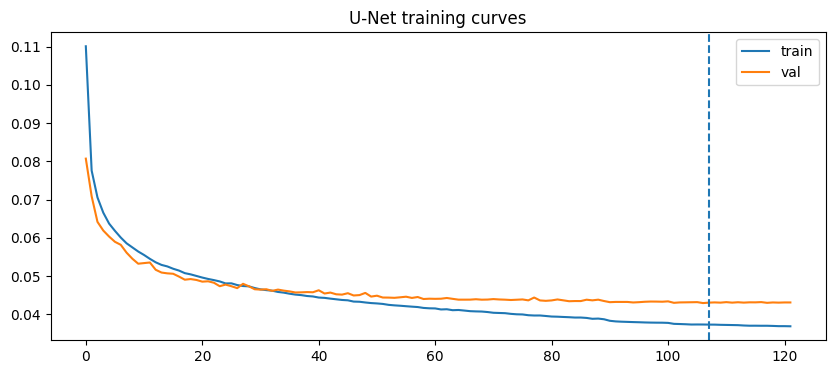

In [16]:
log_path = MODEL_DIR / "training_log.json"
log = json.load(open(log_path))

train_losses = log["train_losses"]
val_losses = log["val_losses"]
best_epoch = log["best_epoch"]

plt.figure(figsize=(10,4))
plt.plot(train_losses, label="train")
plt.plot(val_losses, label="val")
plt.axvline(best_epoch, linestyle="--")
plt.legend()
plt.title("U-Net training curves")
plt.show()

# Why U-Net trains differently than MLP

Compared to the MLP baseline, the U-Net exhibits:

- Faster convergence in early epochs
- More stable validation loss
- Less sensitivity to feature scaling

This is due to convolutional weight sharing, which significantly reduces the number of parameters required to model local spectral patterns.

However, due to higher capacity, it can also overfit more quickly without proper regularization (dropout + early stopping).

# 7. Load model

In [17]:
MODEL_PT = MODEL_DIR / "best_model.pt"

# -----------------------------
# Load normalization stats
# -----------------------------
mean = np.load(MODEL_DIR / "norm_mean.npy")[0]
std  = np.load(MODEL_DIR / "norm_std.npy")[0]

print("Normalization stats loaded")
print("mean:", mean)
print("std :", std)

# -----------------------------
# Load model
# -----------------------------
model = UNet(
    base_filters=32,
    dropout_enc=0.1,
    dropout_bottleneck=0.5,
    dropout_dec=0.1
).to(DEVICE)

state_dict = torch.load(MODEL_PT, map_location=DEVICE, weights_only=True)

missing, unexpected = model.load_state_dict(state_dict, strict=False)

model.eval()

print("─" * 50)
print("U-Net loaded")
print("─" * 50)
print("Device         :", DEVICE)
print("Model params   :", model.count_parameters())
print("─" * 50)

Normalization stats loaded
mean: -5.214179992675781
std : 8.876091967092286
──────────────────────────────────────────────────
U-Net loaded
──────────────────────────────────────────────────
Device         : cuda
Model params   : 7762465
──────────────────────────────────────────────────


# 8. Inference function

In [18]:
def enhance_unet(y):
    D = librosa.stft(y, n_fft=N_FFT, hop_length=HOP_LENGTH)
    mag = np.abs(D)
    phase = np.angle(D)

    x = torch.tensor(mag[None, None, ...], dtype=torch.float32).to(DEVICE)

    with torch.no_grad():
        mask = model(x).cpu().numpy()[0,0]

    enhanced = mag * mask
    y_out = librosa.istft(enhanced * np.exp(1j * phase), hop_length=HOP_LENGTH)

    return y_out, mask, mag

# 9. Audio examples

In [28]:
results = {}

for fname in EXAMPLE_FILES:
    noisy_path = NOISY_DIR / fname
    clean_path = CLEAN_DIR / fname

    y_noisy, _ = sf.read(noisy_path)
    y_clean, _ = sf.read(clean_path)

    y_enh, mask, mag = enhance_unet(y_noisy)

    results[fname] = {
        "clean": y_clean,
        "noisy": y_noisy,
        "enhanced": y_enh,
        "mask": mask
    }

    print(f"Processed: {fname} — duration: {len(y_clean)/SR:.2f}s")

Processed: 00005.wav — duration: 3.96s
Processed: 00009.wav — duration: 4.34s


In [20]:
from IPython.display import Audio, display, HTML

# ── Playback widgets ──────────────────────────────────────────────────────
for fname, r in results.items():
  display(HTML(f"""
  <div style='border:1px solid #ddd; border-radius:8px;
              padding:14px 18px; margin-bottom:16px;
              font-family:sans-serif;'>
    <b style='font-size:15px;'>{fname}</b>
    <table style='margin-top:10px; border-spacing:0 6px;'>
      <tr>
        <td style='width:130px; color:#666; font-size:13px;'>Clean (reference)</td>
        <td></td>
      </tr>
      <tr>
        <td style='color:#666; font-size:13px;'>Noisy (input)</td>
        <td></td>
      </tr>
      <tr>
        <td style='color:#666; font-size:13px;'>U-Net enhanced</td>
        <td></td>
      </tr>
    </table>
  </div>
  """))

  print(f"  ▸ Clean — {fname}:")
  display(Audio(r["clean"], rate=SR))

  print(f"  ▸ Noisy — {fname}:")
  display(Audio(r["noisy"], rate=SR))

  print(f"  ▸ U-Net enhanced — {fname}:")
  display(Audio(r["enhanced"], rate=SR))

  print()

Clean (reference),
Noisy (input),
U-Net enhanced,


  ▸ Clean — 00005.wav:


  ▸ Noisy — 00005.wav:


  ▸ U-Net enhanced — 00005.wav:


Clean (reference),
Noisy (input),
U-Net enhanced,


  ▸ Clean — 00009.wav:


  ▸ Noisy — 00009.wav:


  ▸ U-Net enhanced — 00009.wav:


# 10. Spectogram comparison

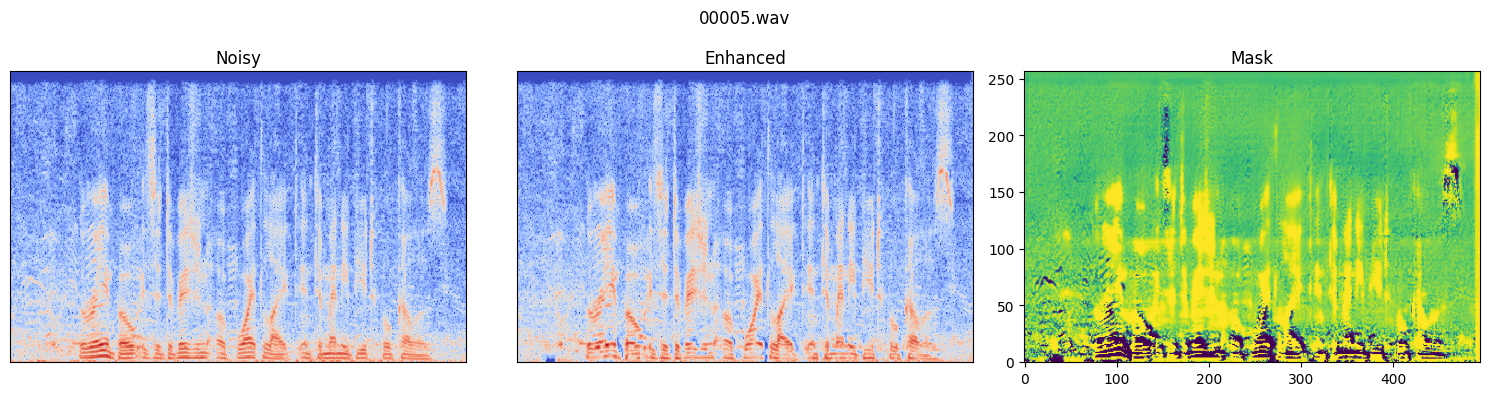

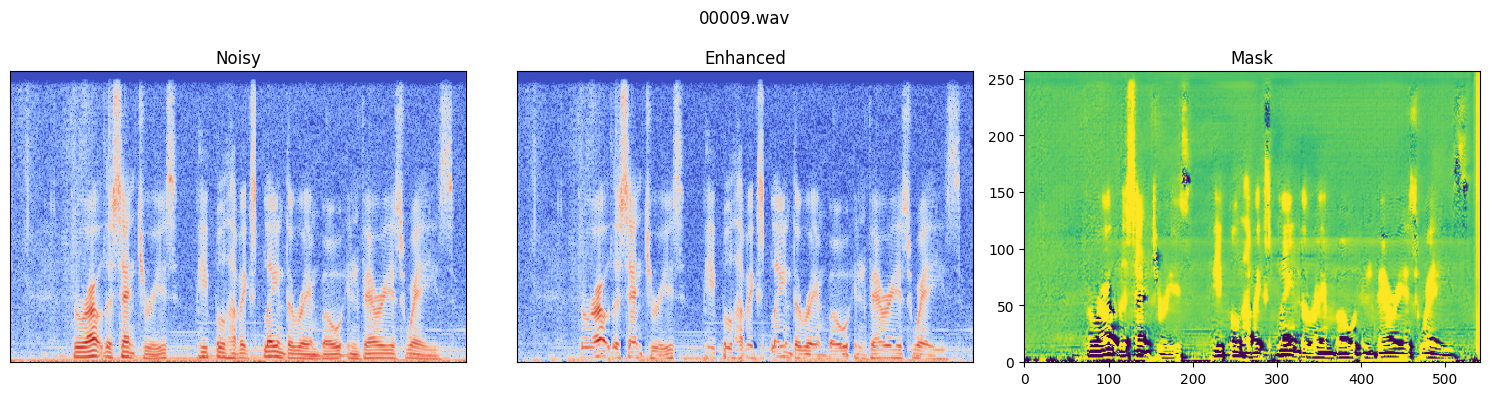

In [21]:
for fname, r in results.items():
    D_n = librosa.stft(r["noisy"], n_fft=N_FFT, hop_length=HOP_LENGTH)
    D_e = librosa.stft(r["enhanced"], n_fft=N_FFT, hop_length=HOP_LENGTH)

    fig, ax = plt.subplots(1,3, figsize=(15,4))

    ax[0].set_title("Noisy")
    librosa.display.specshow(librosa.amplitude_to_db(np.abs(D_n)), sr=SR, ax=ax[0])

    ax[1].set_title("Enhanced")
    librosa.display.specshow(librosa.amplitude_to_db(np.abs(D_e)), sr=SR, ax=ax[1])

    ax[2].set_title("Mask")
    ax[2].imshow(r["mask"], origin="lower", aspect="auto", vmin=0, vmax=1)

    plt.suptitle(fname)
    plt.tight_layout()
    plt.show()

# 11. Evaluation metrics

In [22]:
unet_res = {
  "PESQ": 2.2508,
  "STOI": 0.9243,
  "CSIG": 4.3282,
  "CBAK": 2.7159,
  "COVL": 3.3565,
  "SSNR": 4.8118,
  "SI_SDR": 12.7638
}

mlp_res = json.load(open(RESULTS_DIR / "mlp.json"))["metrics"]
base_res = json.load(open(RESULTS_DIR / "noisy_baseline.json"))["metrics"]
ss_res = json.load(open(RESULTS_DIR / "spectral_subtraction.json"))["metrics"]
gss_res = json.load(open(RESULTS_DIR / "geometric_spectral_subtraction.json"))["metrics"]

In [24]:
import json

# ── Load all results ──────────────────────────────────────────────────────
mlp_res  = json.load(open(RESULTS_DIR / "mlp.json"))["metrics"]
base_res = json.load(open(RESULTS_DIR / "noisy_baseline.json"))["metrics"]
ss_res   = json.load(open(RESULTS_DIR / "spectral_subtraction.json"))["metrics"]
gss_res  = json.load(open(RESULTS_DIR / "geometric_spectral_subtraction.json"))["metrics"]
unet_res = json.load(open(RESULTS_DIR / "unet.json"))["metrics"]

models = {
  "Noisy baseline": base_res,
  "Spectral Sub.": ss_res,
  "Geo. Spec. Sub.": gss_res,
  "MLP (IRM)": mlp_res,
  "U-Net (IRM)": unet_res,
}

# Use any model as reference (U-Net here since it's most complete)
metrics = list(unet_res.keys())

# ── Print table ──────────────────────────────────────────────────────────
print(f"{'Metric':<10}", end="")
for name in models:
  print(f"  {name:>15}", end="")
print()

print("─" * (10 + 18 * len(models)))

for m in metrics:
  print(f"{m:<10}", end="")
  for name, res in models.items():
    v = res.get(m, float("nan"))
    print(f"  {v:>15.4f}", end="")
  print()

Metric       Noisy baseline    Spectral Sub.  Geo. Spec. Sub.        MLP (IRM)      U-Net (IRM)
────────────────────────────────────────────────────────────────────────────────────────────────────
PESQ                 1.9707           2.0390           2.2040           2.0879           2.2508
STOI                 0.9210           0.9140           0.9145           0.8865           0.9244
CSIG                 4.0657           4.2139           4.3211           4.2427           4.3282
CBAK                 2.5884           2.6152           2.6925           2.6381           2.7160
COVL                 3.0795           3.1824           3.3278           3.2254           3.3565
SSNR                 1.5582           4.5953           5.3644           2.7734           4.8118
SI_SDR               8.4455          -0.0065           5.9885           8.5756          12.7638


# Why U-Net improves SI-SDR more strongly than PESQ

The U-Net shows a strong gain in SI-SDR compared to the MLP baseline.

This indicates:

- Better reconstruction of signal energy structure
- More accurate suppression of broadband noise

However, PESQ improvements are more modest because:

- PESQ is sensitive to perceptual artifacts
- Convolutional smoothing can slightly reduce sharp transients

This highlights a common trade-off:
- U-Net improves signal fidelity (SI-SDR)
- Perceptual gains (PESQ) are more incremental

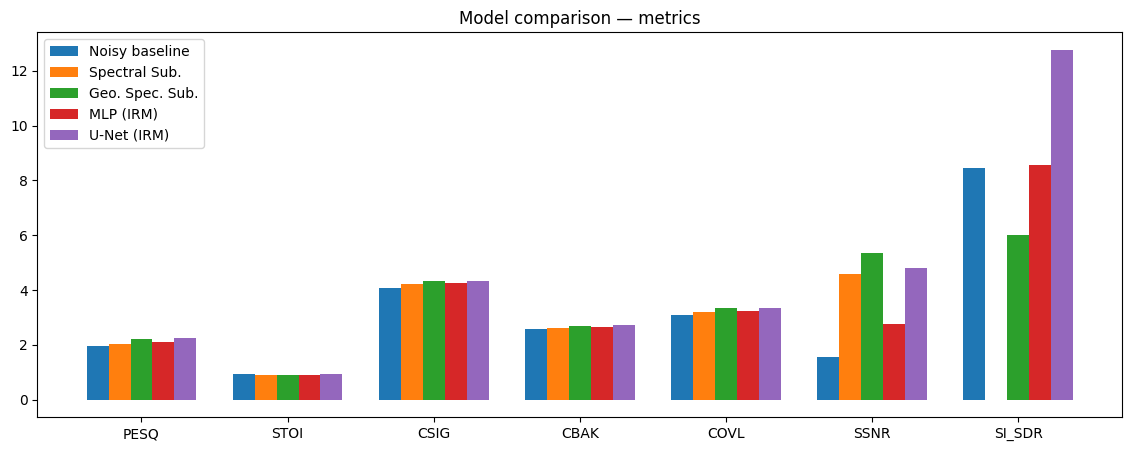

In [25]:
x = np.arange(len(metrics))
width = 0.15

plt.figure(figsize=(14,5))

for i, (name, res) in enumerate(models.items()):
    vals = [res[m] for m in metrics]
    plt.bar(x + i*width, vals, width, label=name)

plt.xticks(x + width*2, metrics)
plt.legend()
plt.title("Model comparison — metrics")
plt.show()

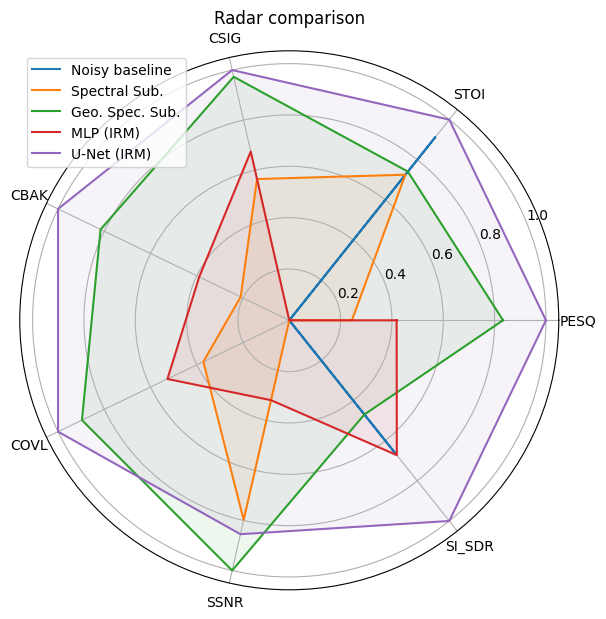

In [26]:
norm_metrics = metrics
raw = {m: [models[n][m] for n in models] for m in norm_metrics}
lo = {m: min(v) for m,v in raw.items()}
hi = {m: max(v) for m,v in raw.items()}

def norm(name):
    return [(models[name][m]-lo[m])/(hi[m]-lo[m]+1e-9) for m in norm_metrics]

angles = np.linspace(0, 2*np.pi, len(metrics), endpoint=False).tolist()
angles += angles[:1]

plt.figure(figsize=(7,7))
ax = plt.subplot(111, polar=True)

for name in models:
    vals = norm(name)+[norm(name)[0]]
    ax.plot(angles, vals, label=name)
    ax.fill(angles, vals, alpha=0.08)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(metrics)
plt.legend()
plt.title("Radar comparison")
plt.show()

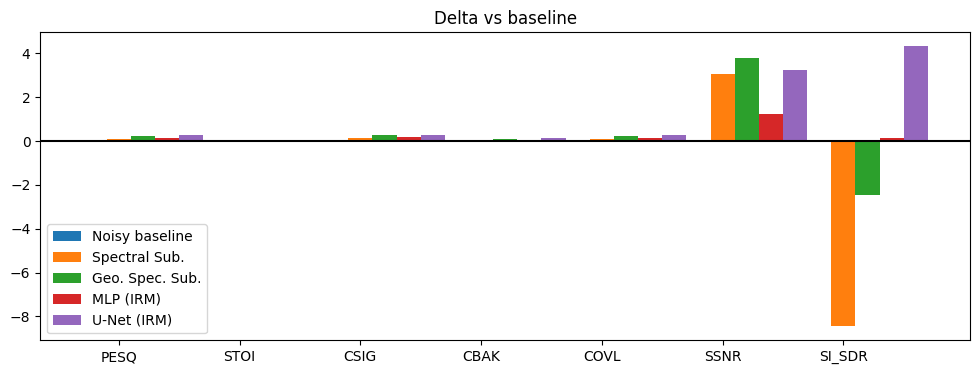

In [27]:
x = np.arange(len(metrics))
width = 0.2

plt.figure(figsize=(12,4))

for i,(name,res) in enumerate(models.items()):
    if name == "Noisy":
        continue
    deltas = [res[m]-base_res[m] for m in metrics]
    plt.bar(x+i*width, deltas, width, label=name)

plt.axhline(0, color="black")
plt.xticks(x+width, metrics)
plt.legend()
plt.title("Delta vs baseline")
plt.show()

# Summary

Compared to the MLP baseline, the U-Net consistently performs better on most metrics.

Key differences:

| Aspect | MLP | U-Net |
|--------|-----|-------|
| Input representation | Flattened temporal window | 2D spectrogram |
| Feature learning | Fully connected | Local convolution |
| Structural bias | Weak | Strong (image-like priors) |
| Performance ceiling | Limited | Higher |

### Why U-Net performs better

The U-Net benefits from an inductive bias aligned with the structure of speech:

- Speech harmonics are local in frequency
- Phonemes evolve smoothly in time
- Noise is often spatially localized in the spectrogram

Convolutional layers naturally exploit these properties, while the MLP must learn them from scratch.